# CoRal Conversation Dataset

In [1]:
print('h')

h


In [22]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from operator import itemgetter
import itertools

In [3]:
df = pd.read_json('/root/master_thesis/thesis_multi_speaker_asr/src/hpc_results/int8_cputhreads12/asr_output_coral_segments_chunking.jsonl', lines=True)
print(df.columns)

Index(['start', 'end', 'wer', 'cer', 'text', 'avg_logprob', 'metadata'], dtype='str')


In [34]:
def fetch_results(path):
    age_buckets = [18, 29, 39, 49, 59, 60] # Buckets: [<18], [18-29], [30-39], [40-49], [50, 59], [60+]
    records = []
    with open(path, 'r') as file:
        for line in file:
            line = line.strip()
            record = json.loads(line)
            metadata = record['metadata']
            segments = [seg for seg in metadata['segments']]
            age = set([seg['age'] for seg in segments]).pop()
            if age >= age_buckets[-1]:
                bucket = len(age_buckets) - 1
            else:
                bucket = [age_buckets.index(ex) for ex in age_buckets if age <= ex][0]
            speaker_id = set([seg['id_speaker'] for seg in segments]).pop()
            gender = set([seg['gender'] for seg in segments]).pop()
            new_record = {
                'wer': record['wer'],
                'cer': record['cer'],
                'speaker': speaker_id,
                'age': age,
                'age_bucket': bucket,
                'gender': gender
            }
            records.append(new_record)
    return records


In [36]:
results_int8_threads12 = fetch_results('/root/master_thesis/thesis_multi_speaker_asr/src/hpc_results/int8_cputhreads12/asr_output_coral_segments_chunking.jsonl')
results_int8_threads10 = fetch_results('/root/master_thesis/thesis_multi_speaker_asr/src/hpc_results/int8_cputhreads10/asr_output_coral_segments_chunking.jsonl')
results_float32_threads12 = fetch_results('/root/master_thesis/thesis_multi_speaker_asr/src/hpc_results/float32_cputhreads12/asr_output_coral_segments.jsonl')
results_float32_threads10 = fetch_results('/root/master_thesis/thesis_multi_speaker_asr/src/hpc_results/float32_cputhreads10/asr_output_coral_segments.jsonl')


In [37]:
def get_grouped_results(group_condition: str, results: list):
    sorted_results = sorted(results, key=itemgetter(group_condition))
    grouped_wer = {}
    grouped_cer = {}
    for key, group in itertools.groupby(sorted_results, lambda x: x[group_condition]):
        group = list(group)
        group_wer = [g['wer'] for g in group]
        if len(group_wer) < 1:
            continue
        grouped_wer[key] = sum(group_wer) / len(group_wer)

        group_cer = [g['cer'] for g in group]
        if len(group_cer) < 1:
            continue
        grouped_cer[key] = sum(group_cer) / len(group_cer)
    return grouped_cer, grouped_wer


In [45]:
def plot_exp1(task_type, int8_cer, int8_wer, float32_cer, float32_wer):
    if task_type == 'Gender':
        groups = ["Female", "Male"]
        wer_fp32 = [float32_wer.get('female'), float32_wer.get('male')]
        wer_int8 = [int8_wer.get('female'), int8_wer.get('male')]

        cer_fp32 = [float32_cer.get('female'), float32_cer.get('male')]
        cer_int8 = [int8_cer.get('female'), int8_cer.get('male')]
    elif task_type == 'Age':
        groups = ["18–29", "30–39", "40–49", "50–59", "60+"]
        wer_fp32 = [float32_wer.get(1), float32_wer.get(2), float32_wer.get(3), float32_wer.get(4), float32_wer.get(5)]
        wer_int8 = [int8_wer.get(1), int8_wer.get(2), int8_wer.get(3), int8_wer.get(4), int8_wer.get(5)]

        cer_fp32 = [float32_cer.get(1), float32_cer.get(2), float32_cer.get(3), float32_cer.get(4), float32_cer.get(5)]
        cer_int8 = [int8_cer.get(1), int8_cer.get(2), int8_cer.get(3), int8_cer.get(4), int8_cer.get(5)]

    x = np.arange(len(groups))
    width = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=False)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=2,
        frameon=False,
        bbox_to_anchor=(0.5, 1.02),
    )
    for ax in axes:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.4)
        ax.set_axisbelow(True)

    # WER
    axes[0].bar(x - width/2, wer_fp32, width, label="Float32")
    axes[0].bar(x + width/2, wer_int8, width, label="Int8")
    axes[0].set_title("WER")
    axes[0].set_ylim(0, 0.35)
    axes[0].set_ylabel("WER (%)")
    axes[0].set_xlabel(task_type)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(groups)
    axes[0].grid(axis="y", alpha=0.3)
    axes[0].legend(frameon=False)

    # CER
    axes[1].bar(x - width/2, cer_fp32, width)
    axes[1].bar(x + width/2, cer_int8, width)
    axes[1].set_title("CER")
    axes[1].set_ylim(0, 0.35)
    axes[1].set_ylabel("CER (%)")
    axes[1].set_xlabel(task_type)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(groups)
    axes[1].grid(axis="y", alpha=0.3)

    plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    })
    plt.tight_layout()
    plt.show()

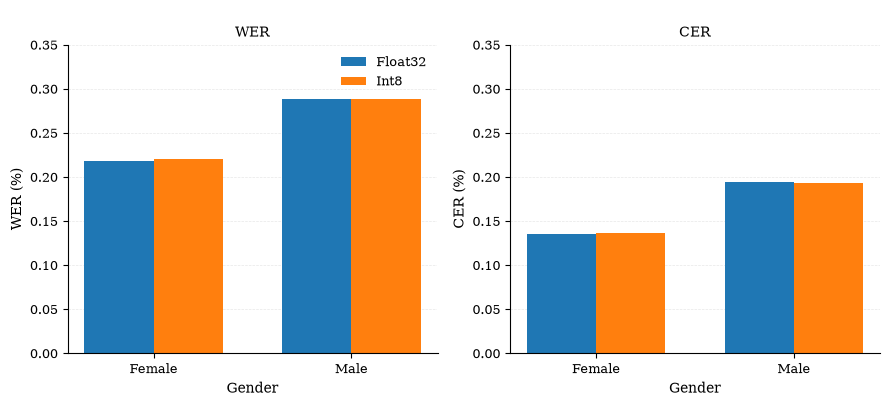

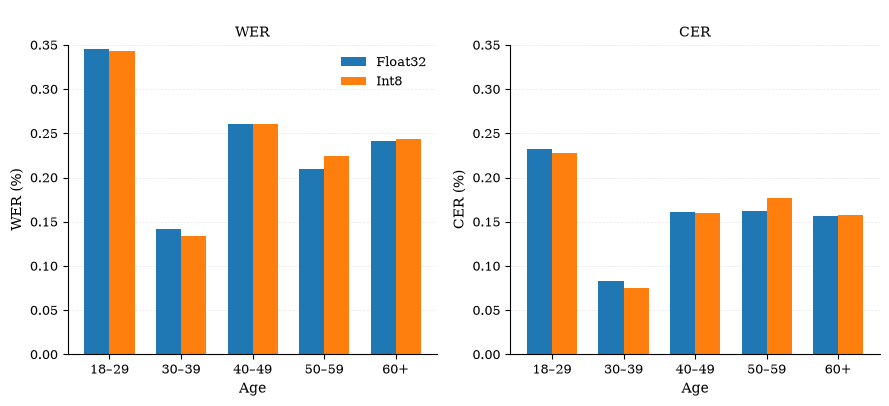

In [46]:
float32_10_cer, float32_10_wer = get_grouped_results('gender', results_float32_threads10)
float32_12_cer, float32_12_wer = get_grouped_results('gender', results_float32_threads12)
int8_12_cer, int8_12_wer = get_grouped_results('gender', results_int8_threads12)
int8_10_cer, int8_10_wer = get_grouped_results('gender', results_int8_threads10)
#plot_exp1('gender', int8_12_cer, int8_12_wer, float32_12_cer, float32_12_wer)
plot_exp1('Gender', int8_10_cer, int8_10_wer, float32_10_cer, float32_10_wer)


float32_10_cer, float32_10_wer = get_grouped_results('age_bucket', results_float32_threads10)
float32_12_cer, float32_12_wer = get_grouped_results('age_bucket', results_float32_threads12)
int8_12_cer, int8_12_wer = get_grouped_results('age_bucket', results_int8_threads12)
int8_10_cer, int8_10_wer = get_grouped_results('age_bucket', results_int8_threads10)
#plot_exp1('age', int8_12_cer, int8_12_wer, float32_12_cer, float32_12_wer)
plot_exp1('Age', int8_10_cer, int8_10_wer, float32_10_cer, float32_10_wer)